In [107]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import json
from scipy import integrate

In [38]:
model_variants = [
    "yolov5nu.pt",
    "yolov5su.pt",
    "yolov5mu.pt",
    "yolov5lu.pt",
]
results_dir = Path("raw_data/prebuilt_models")


In [39]:
def read_model(model_name):
    power_df = pd.read_csv(results_dir / model_name / f"{model_name}_power_log.log", names=["time", "voltage", "current"], parse_dates=[0])
    with open(results_dir / model_name / f"{model_name}_pytorch.json") as f:
        timings = json.load(f)
    with open(results_dir / model_name / "validation_results.json") as f:
        results = json.load(f)
    return power_df, timings, results


In [47]:
idle_power = 3866444.4022208513

In [158]:
def calculate_metrics(model_name: str, plot=False):
    """Calculates metrics and returns a dict with all metrics for a given model measurements.

    'Active' part is defined as part of the time series between the first and the last instance 
    of power readings above a certain arbitrary threshold, e.g. 1 W.
    

    Returns: 
        a dict of:
        "mean_active_power": mean power of the 'active' part of the measurements in W
        "max_active_power": max power of the 'active' part of the measurements in W
        "wall_time": time we recorded before and after validation method was called in sec
        "active_time": time taken by the 'active' part of the measurements in sec
        "inference_time": inference time as reported by ultralytics in sec
        "mean_active_energy": energy according to mean power and active time in J
        "max_active_energy": energy according to max power and active time in J
        "mean_inference_energy": energy according to mean power and inference time in J
        "max_inference_energy": energy according to max power and inference time in J
        "integrated_energy": energy by integration (trapezoid method) in J
    """
    power_df, timings, ultralytics_results = read_model(model_name)
    
    start_time = pd.to_datetime(timings["start_time"], unit='s')
    end_time = pd.to_datetime(timings["end_time"], unit='s')
    wall_time = (end_time - start_time).total_seconds()
    inference_time = ultralytics_results["speed"]["inference"]
    power_profile = power_df[(power_df.time >= start_time) & (power_df.time <= end_time)]
    # Get power profile subtracting the idle power
    power_profile.loc[:, ["power"]] = (power_profile.current * power_profile.voltage - idle_power) / 10**6

    # Get framework overhead power (the low parts before and after active part)
    framework_power_overhead = power_profile.power.iloc[:10000].mean()
    power_profile.loc[:, "power"] = (power_profile.power - framework_power_overhead)
    filtered_time = power_profile[power_profile.power > 1].time
    active_power_profile = power_profile.loc[(power_df.time >= filtered_time.min()) & (power_df.time <= filtered_time.max())]

    if plot:
        sns.lineplot(power_profile, x="time", y="power")
        sns.lineplot(active_power_profile, x="time", y="power")
        plt.show()

    mean_active_power = active_power_profile.power.mean()
    max_active_power = active_power_profile.power.max()
    active_time = (active_power_profile.time.iloc[-1] - active_power_profile.time.iloc[0]).total_seconds()
    integrated_energy = integrate.trapezoid(active_power_profile.power, x=active_power_profile.time.apply(lambda x: x.timestamp()))
    result = {
        "mean_active_power": mean_active_power,
        "max_active_power": max_active_power,
        "wall_time": wall_time,
        "active_time": active_time,
        "inference_time": inference_time,
        "mean_active_energy": mean_active_power * active_time,
        "max_active_energy": max_active_power * active_time,
        "mean_inference_energy": mean_active_power * inference_time,
        "max_inference_energy": max_active_power * inference_time,
        "integrated_energy": integrated_energy,
    }
    result.update(ultralytics_results["metrics"])
    return result


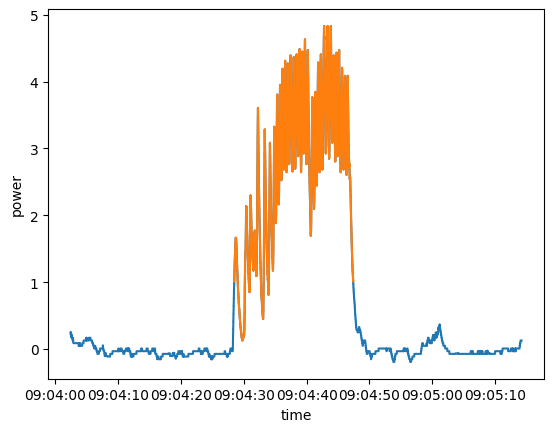

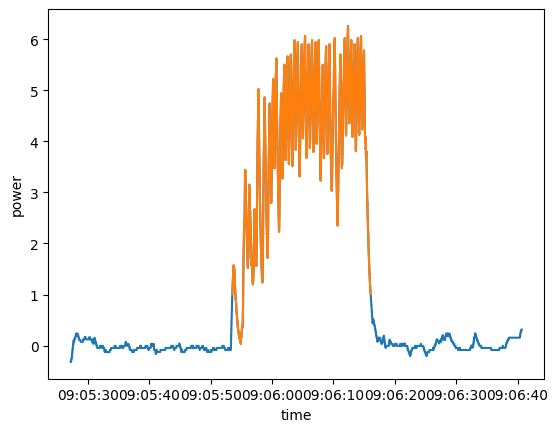

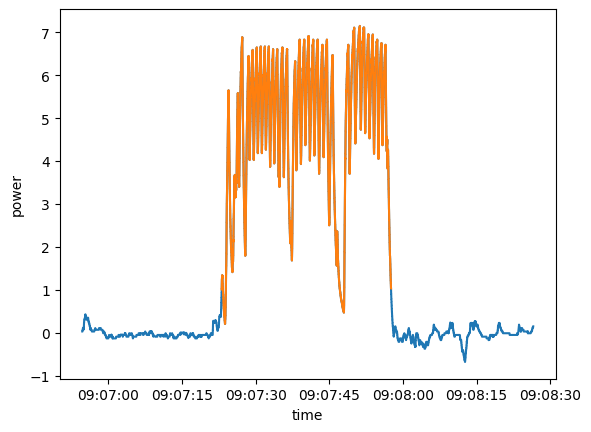

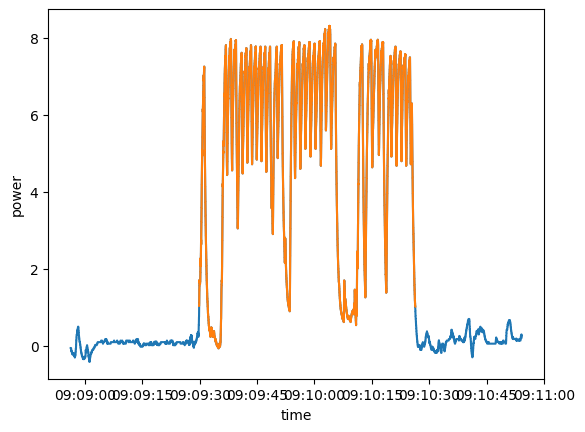

In [160]:
measurements_df = pd.DataFrame({model_name: calculate_metrics(model_name, plot=True) for model_name in model_variants}).T

In [161]:
measurements_df

,mean_active_power,max_active_power,wall_time,active_time,inference_time,mean_active_energy,max_active_energy,mean_inference_energy,max_inference_energy,integrated_energy,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness
yolov5nu.pt,2.685529,4.832185,71.789034,18.941966,16.142004,50.869194,91.531078,43.349817,78.001147,50.762136,0.618834,0.448957,0.512961,0.362617,0.377651
yolov5su.pt,3.845952,6.259711,73.449729,22.546462,24.756256,86.712616,141.134328,95.211376,154.966996,87.314214,0.707479,0.554327,0.621299,0.462910,0.478748
yolov5mu.pt,4.787562,7.151867,91.828520,34.477659,50.461442,165.063927,246.579637,241.587276,360.893526,166.036098,0.697522,0.633008,0.672503,0.517589,0.533080
yolov5lu.pt,5.134037,8.316567,117.872597,56.487255,86.664725,290.007682,469.780020,444.939941,720.752959,292.862289,0.743440,0.638562,0.707172,0.555185,0.570383


<Axes: title={'center': 'YOLOv5 Baseline'}, xlabel='mAP50-95', ylabel='Valdation Energy Consumption (J)'>

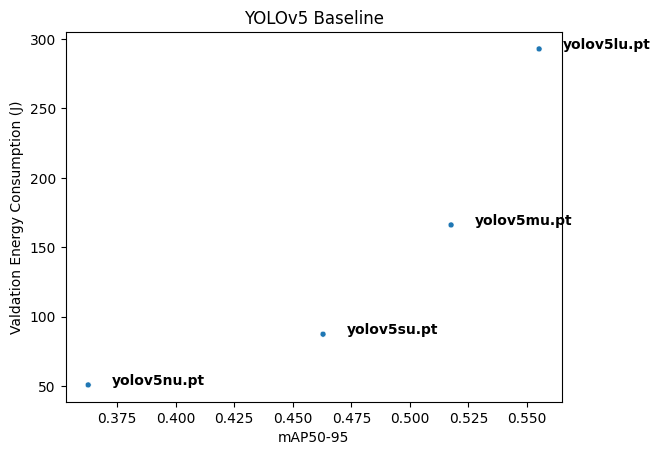

In [164]:
def scatter_text(x, y, text_column, data, title, xlabel, ylabel):
    """Scatter plot with country codes on the x y coordinates
       Based on this answer: https://stackoverflow.com/a/54789170/2641825"""
    # Create the scatter plot
    p1 = sns.scatterplot(x=x, y=y, data=data, size = 8, legend=False)
    # Add text besides each point
    for line in range(0,data.shape[0]):
         p1.text(data[x][line]+0.01, data[y][line], 
                 data[text_column][line], horizontalalignment='left', 
                 size='medium', color='black', weight='semibold')
    # Set title and axis labels
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    return p1

scatter_text("integrated_energy", "metrics/mAP50-95(B)", "index", data=measurements_df.reset_index(), title="YOLOv5 Baseline", xlabel="Valdation Energy Consumption (J)", ylabel="mAP50-95")


In [162]:
measurements_df.to_csv("raw_data/prebuilt_models_measurements.csv")